# UK Telecom Customer Switching Behaviour Analysis
### Ofcom Switching Tracker 2023

This project analyses customer switching behaviour in the UK telecommunications market using the Ofcom Switching Tracker dataset.

The objective is to understand how frequently customers switch telecom providers and identify the factors that influence switching behaviour.

Rather than focusing only on descriptive statistics, the analysis aims to translate switching patterns into actionable insights that can support telecom customer retention strategies.

The analysis focuses on:

- Broadband provider switching behaviour
- Customer motivations for switching providers
- Switching barriers and customer inertia
- Strategic implications for telecom retention decision framework

## Dataset Source

Dataset: Ofcom Switching Tracker 2023 – Respondent Level Data  
Source: Ofcom Open Data Portal

The Switching Tracker dataset contains survey responses from UK consumers regarding their experiences switching telecommunications service providers.

The survey captures behavioural and perception data including:

- Whether customers switched providers
- Which services were switched (broadband, mobile, etc.)
- Reasons for switching providers
- Customer satisfaction indicators
- Market competition perceptions

The dataset contains 2,717 survey respondents and nearly 2,000 variables representing structured survey questions.

## Step 1 - Broadband Switching Behaviour

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("switching-tracker-2023-respondent-level-data.csv")
df.head()

,IOBS,P_METHOD_TYPE,S1,OS1B,S4,S5,QS6A,QS6B,QS6C,QS6D,...,Q242526B_BUNSH,Q242526B_BUNSI,Q242526B_BUNSJ,Q242526B_BUNSK,Q242526B_BUNSL,ANYBUNINDEX,QUADINDEX,TPINDEX,DPINDEX,WT1
0,60,3,1,5,3,1,1,0,0,0,...,0,0,0,0,0,,,,,1.1071
1,61,3,1,5,2,2,1,0,0,0,...,0,0,0,0,0,,,,,1.1576
2,62,3,1,8,3,1,0,1,0,0,...,0,0,0,0,1,5,,,5,1.0695
3,63,3,1,6,4,1,1,0,0,0,...,0,0,0,0,0,2,,,,1.0172
4,65,3,1,3,1,1,0,1,0,0,...,0,0,0,0,0,,,,,1.6809


In [5]:
df.shape

(2717, 1985)

In [6]:
df.columns

Index(['IOBS', 'P_METHOD_TYPE', 'S1', 'OS1B', 'S4', 'S5', 'QS6A', 'QS6B',
       'QS6C', 'QS6D',
       ...
       'Q242526B_BUNSH', 'Q242526B_BUNSI', 'Q242526B_BUNSJ', 'Q242526B_BUNSK',
       'Q242526B_BUNSL', 'ANYBUNINDEX', 'QUADINDEX', 'TPINDEX', 'DPINDEX',
       'WT1'],
      dtype='object', length=1985)

In [7]:
[c for c in df.columns if "switch" in c.lower()]

['ANYSWITCHA',
 'ANYSWITCHB',
 'ANYSWITCHC',
 'ANYSWITCHD',
 'ANYSWITCHE',
 'ANYSWITCHF',
 'ANYSWITCH2A',
 'ANYSWITCH2B',
 'ANYSWITCH2C',
 'ANYSWITCH2D',
 'ANYSWITCH2E',
 'ANYSWITCH2F']

In [8]:
[c for c in df.columns if "services" in c.lower()]

[]

In [9]:
[c for c in df.columns if "price" in c.lower()]

[]

In [10]:
df['ANYSWITCHB'].value_counts()

,count
ANYSWITCHB,
0,2495
1,222


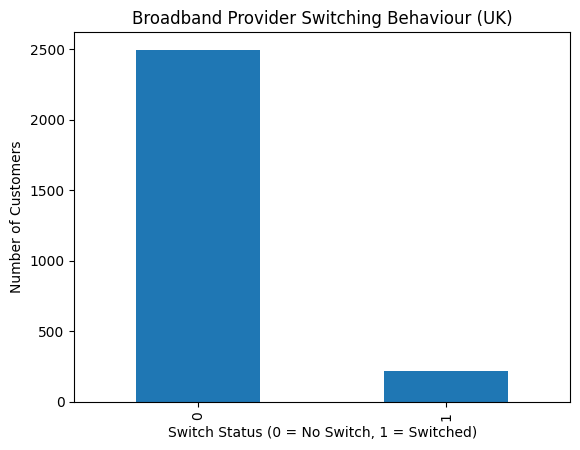

In [11]:
df['ANYSWITCHB'].value_counts().plot(kind='bar')

plt.title("Broadband Provider Switching Behaviour (UK)")
plt.xlabel("Switch Status (0 = No Switch, 1 = Switched)")
plt.ylabel("Number of Customers")

plt.show()

## Insight

The analysis indicates that only a small proportion of UK broadband customers switched providers during the observed period.

Approximately 8% of respondents reported switching broadband providers, while the majority remained with their existing provider.

This suggests that switching barriers, contract structures, or customer inertia may play an important role in telecom customer retention dynamics.

In [13]:
[c for c in df.columns if "reason" in c.lower()]

[]

In [14]:
[c for c in df.columns if "QS6" in c]

['QS6A', 'QS6B', 'QS6C', 'QS6D', 'QS6E', 'QS6F', 'QS6G']

In [15]:
df[['QS6A', 'QS6B', 'QS6C', 'QS6D', 'QS6E', 'QS6F', 'QS6G']].head()

,QS6A,QS6B,QS6C,QS6D,QS6E,QS6F,QS6G
0,1,0,0,0,0,1,0
1,1,0,0,0,0,1,0
2,0,1,0,0,0,1,0
3,1,0,0,0,0,1,0
4,0,1,0,0,0,1,0


In [16]:
df[['QS6A', 'QS6B', 'QS6C', 'QS6D', 'QS6E', 'QS6F', 'QS6G']].sum()

,0
QS6A,786
QS6B,751
QS6C,530
QS6D,622
QS6E,28
QS6F,1537
QS6G,1152


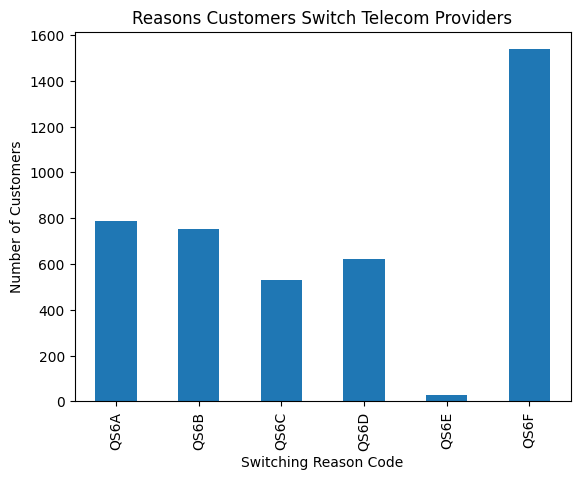

In [17]:
reasons = df[['QS6A','QS6B','QS6C','QS6D','QS6E','QS6F']].sum()

reasons.plot(kind='bar')

plt.title("Reasons Customers Switch Telecom Providers")
plt.xlabel("Switching Reason Code")
plt.ylabel("Number of Customers")

plt.show()

## Switching Drivers Insight

The analysis highlights that telecom switching behaviour is driven by a combination of price sensitivity, service dissatisfaction, and competitive offers.

Understanding these drivers allows telecom providers to design proactive retention strategies rather than reacting only after customers leave.

In [18]:
[c for c in df.columns if c.startswith("QS6")]

['QS6A', 'QS6B', 'QS6C', 'QS6D', 'QS6E', 'QS6F', 'QS6G']

In [19]:
df[['QS6A', 'QS6B', 'QS6C', 'QS6D', 'QS6E', 'QS6F', 'QS6G']].head()

,QS6A,QS6B,QS6C,QS6D,QS6E,QS6F,QS6G
0,1,0,0,0,0,1,0
1,1,0,0,0,0,1,0
2,0,1,0,0,0,1,0
3,1,0,0,0,0,1,0
4,0,1,0,0,0,1,0


In [20]:
reason_counts = df[['QS6A','QS6B','QS6C','QS6D','QS6E','QS6F']].sum()
reason_counts

,0
QS6A,786
QS6B,751
QS6C,530
QS6D,622
QS6E,28
QS6F,1537


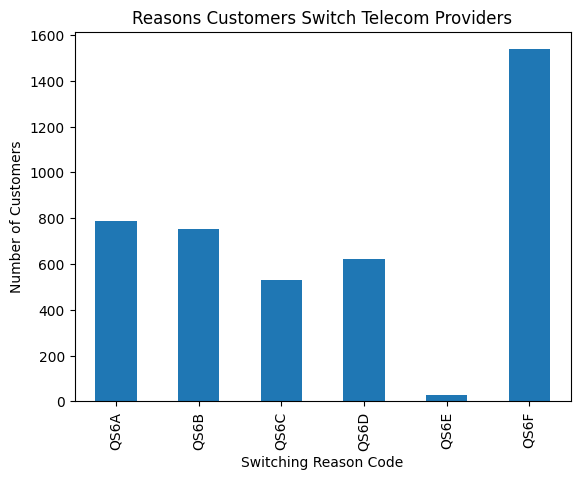

In [21]:
reason_counts.plot(kind='bar')

plt.title("Reasons Customers Switch Telecom Providers")
plt.xlabel("Switching Reason Code")
plt.ylabel("Number of Customers")

plt.show()

##Switching Drivers Insight
The data suggests that customers who switch telecom providers tend to be motivated by a limited set of key drivers. These drivers may include pricing competitiveness, service quality concerns, and attractive promotional offers from alternative providers. Identifying these triggers allows telecom operators to design targeted retention strategies before switching behaviour occurs.

## Step 2 - Reasons Customers Switch Telecom Providers

In [24]:
[c for c in df.columns if c.startswith("QS6")]

['QS6A', 'QS6B', 'QS6C', 'QS6D', 'QS6E', 'QS6F', 'QS6G']

In [25]:
reason_counts = df[['QS6A', 'QS6B', 'QS6C', 'QS6D', 'QS6E', 'QS6F', 'QS6G']].sum()

In [26]:
reason_counts

,0
QS6A,786
QS6B,751
QS6C,530
QS6D,622
QS6E,28
QS6F,1537
QS6G,1152


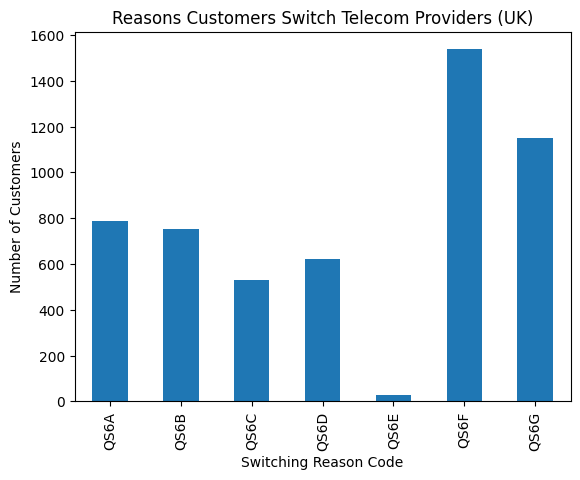

In [27]:
reason_counts.plot(kind='bar')

plt.title("Reasons Customers Switch Telecom Providers (UK)")
plt.xlabel("Switching Reason Code")
plt.ylabel("Number of Customers")

plt.show()

## Insight

The analysis shows that customers who switch telecom providers tend to be influenced by a small number of key drivers.

These drivers often include pricing competitiveness, dissatisfaction with service quality, and attractive promotional offers from competing providers.

Understanding these switching triggers allows telecom operators to design proactive retention strategies that address customer concerns before switching behaviour occurs.

In [28]:
[c for c in df.columns if "sat" in c.lower()]

[]

In [29]:
[c for c in df.columns if c.startswith("Q")]

['QS6A',
 'QS6B',
 'QS6C',
 'QS6D',
 'QS6E',
 'QS6F',
 'QS6G',
 'QS7A',
 'QS7B',
 'QS7C',
 'QS7D',
 'QS7E',
 'QS7F',
 'QS7G',
 'QS7H',
 'QS7I',
 'Q1A',
 'Q1B',
 'Q1C',
 'Q1D',
 'Q1E',
 'Q2AA',
 'Q2A',
 'Q2BA',
 'Q2BB',
 'Q2BC',
 'Q2BD',
 'Q2BE',
 'Q2BF',
 'Q2BG',
 'Q2BH',
 'Q2C_1A',
 'Q2C_1B',
 'Q2C_1C',
 'Q2C_1D',
 'Q2C_1E',
 'Q2C_1F',
 'Q2C_1G',
 'Q2C_2A',
 'Q2C_2B',
 'Q2C_2C',
 'Q2C_2D',
 'Q2C_2E',
 'Q2C_2F',
 'Q2C_2G',
 'Q2C_3A',
 'Q2C_3B',
 'Q2C_3C',
 'Q2C_3D',
 'Q2C_3E',
 'Q2C_3F',
 'Q2C_3G',
 'Q2C_4A',
 'Q2C_4B',
 'Q2C_4C',
 'Q2C_4D',
 'Q2C_4E',
 'Q2C_4F',
 'Q2C_4G',
 'Q2C_5A',
 'Q2C_5B',
 'Q2C_5C',
 'Q2C_5D',
 'Q2C_5E',
 'Q2C_5F',
 'Q2C_5G',
 'Q3A',
 'Q3B',
 'Q3C',
 'Q3D',
 'Q3E',
 'Q4AA',
 'Q4AB',
 'Q4AC',
 'Q4AD',
 'Q4AE',
 'Q4AF',
 'Q4AG',
 'Q4AH',
 'Q4AI',
 'Q4AJ',
 'Q4AK',
 'Q4AL',
 'Q4AM',
 'Q4AN',
 'Q4AO',
 'Q4BA',
 'Q4BB',
 'Q4BC',
 'Q4BD',
 'Q4BE',
 'Q4BF',
 'Q4BG',
 'Q4BH',
 'Q4BI',
 'Q4BJ',
 'Q4BK',
 'Q4BL',
 'Q4BM',
 'Q4BN',
 'Q5A',
 'Q5B',
 'Q5C',
 'Q5D',
 'Q5E',
 

## Telecom Customer Retention Decision Framework

The switching behaviour analysis indicates that while most customers remain with their telecom provider, a measurable proportion actively switch providers.

Understanding the drivers behind switching behaviour enables telecom operators to implement proactive customer retention strategies.

Based on the observed switching patterns and switching drivers identified in this analysis, telecom providers can develop targeted interventions designed to reduce customer churn risk.

### Retention Strategy Framework

Level 1 — Early Risk Monitoring  
Telecom operators should monitor early indicators of switching intent, including pricing sensitivity, dissatisfaction signals, and contract renewal periods.

Level 2 — Targeted Retention Intervention  
Customers showing switching signals should receive targeted retention actions such as loyalty discounts, service upgrades, or personalised support.

Level 3 — Competitive Retention Response  
Where switching likelihood becomes high, telecom providers may deploy stronger retention incentives such as bundled offers, contract renegotiation, or promotional pricing.

## Strategic Insight

Although the overall broadband switching rate is relatively low, switching behaviour appears to be influenced by a limited number of key drivers.

For telecom providers operating in competitive UK markets, early identification of switching triggers is critical for building sustainable customer retention strategies.